### MODEL TRAINING


In [1]:
import slideflow as sf

# # Load a project and dataset
project = sf.load_project('/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo')
dataset = project.dataset(sources=['Exp2_Dataset'])


In [2]:
dataset.summary()

Overview:
╒═════════════════════╤════════════════════════════════════════════════════════════════════════╕
│ Configuration file: │ /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/datasets.json │
│ Tile size (px):     │                                                                        │
│ Tile size (um):     │                                                                        │
│ Slides:             │ 77                                                                     │
│ Patients:           │ 77                                                                     │
│ Slides with ROIs:   │ 77                                                                     │
│ Patients with ROIs: │ 77                                                                     │
╘═════════════════════╧════════════════════════════════════════════════════════════════════════╛

Filters:
╒═══════════════╤════╕
│ Filters:      │ {} │
├───────────────┼────┤
│ Filter Blank: │ [] │
├──────────────

In [3]:
trainval = dataset.filter({'dataset': ['train', 'val']})


In [4]:
trainval.summary()

Overview:
╒═════════════════════╤════════════════════════════════════════════════════════════════════════╕
│ Configuration file: │ /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/datasets.json │
│ Tile size (px):     │                                                                        │
│ Tile size (um):     │                                                                        │
│ Slides:             │ 60                                                                     │
│ Patients:           │ 77                                                                     │
│ Slides with ROIs:   │ 60                                                                     │
│ Patients with ROIs: │ 60                                                                     │
╘═════════════════════╧════════════════════════════════════════════════════════════════════════╛

Filters:
╒═══════════════╤═══════════════════════════════╕
│ Filters:      │ {'dataset': ['train', 'val']} │
├──────

In [ ]:
# project.add_source(
#   name="Exp1",
#   slides="/home/stanna/labshare/SLIDES/PDCD10",
#   roi="/home/stanna/labshare/PROJECTS/PDCD10/rois/anna",
#   tiles="/home/stanna/labshare/PERSONAL/stanna/DATA/Exp1/tiles",
#   tfrecords="/home/stanna/labshare/PERSONAL/stanna/DATA/Exp1/tfrecords"
# )

[04:06:46] INFO     Saved dataset source Exp1 to                                                                   
                    /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/datasets.json

In [5]:
EXPORT_DIR = "/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/seg_export"
#my multiclass labels (match the csvs)
labels = ['Benign', 'Dysplasia', 'Invasive carcinoma']

In [6]:
from slideflow import segment

#exporting thumbnails and masks (more computationally efficient)
segment.export_thumbs_and_masks(
    trainval,
    mpp=20,
    dest=EXPORT_DIR,
    mode='multiclass',
    labels=labels
)


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating data for 60 slides (mode='multiclass', overwrite=False).
Labels: ['Benign', 'Dysplasia', 'Invasive carcinoma']
Skipping slides with no ROIs.


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

TIFFFetchDirectory: /home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AG039F.svs: Can not read TIFF directory count.
TIFFReadDirectory: Failed to read directory at offset 531274856.


Exported data for 59 slides.


In [7]:
import os

PROJECT_PATH = "/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo"
EXPORT_DIR = "/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/seg_export"
RUN_DIR = "/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/models/seg_multiclass_v6"

project = sf.load_project(PROJECT_PATH)
# dataset line removed - already defined in cell 2 with Exp2_Dataset source

labels = ['Benign', 'Dysplasia', 'Invasive carcinoma']

os.makedirs(RUN_DIR, exist_ok=True)

#create config object
config = segment.SegmentConfig(
    mpp=20,
    size=1024,
    mode="multiclass",
    labels=labels,
    arch="Unet",
    encoder_name="resnet34",
    train_batch_size=2,
    epochs=30,
    lr=1e-4,
)

In [8]:
#use config and dataset object to train model! 

history = segment.train(
    config=config,
    dataset=trainval,
    data_source=EXPORT_DIR,   # <--- USE EXPORTED THUMBS/MASKS
    dest=RUN_DIR,
)

Using 60 slides with non-empty ROIs.
Training from pre-generated thumbnails and masks.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA RTX A5000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Unet     │ 24.4 M │ train │     0 │
│ 1 │ loss_fn │ DiceLoss │      0 │ train │     0 │
└───┴─────────┴──────────┴────────┴───────┴───────┘

Trainable params: 24.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.4 M                                                                                               
Total estimated model params size (MB): 97                                                                         
Modules in train mode: 189                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/slideflow/segment/data.py:167: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  output = torch.load(self.paths[index

Saved model to /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/models/seg_multiclass_v6/model.pth


In [ ]:
#now we can load the model 
from slideflow import segment
import numpy as np
import matplotlib.pyplot as plt

MODEL_PATH = "/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/models/seg_multiclass_v5/model.pth"
SLIDE_PATH = "/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/slides/AH141F.svs"  # or any of your 10

model, trained_config = segment.load_model_and_config(MODEL_PATH)


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/slideflow/segment/__init__.py:385: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load

In [ ]:
# and now use the loaded model! 

# Run whole-slide inference at the config's mpp
pred = model.run_slide_inference(SLIDE_PATH)
print(pred.shape)

#For the shape, think of it like each channel (classes + 1) gets a "full image". SO channel 0, which represetnts backgorund has a H x W image, where each pixel = probabilty it's background

[21:28:23] INFO     No ROI for AH141F, using whole slide.

(4, 912, 1024)


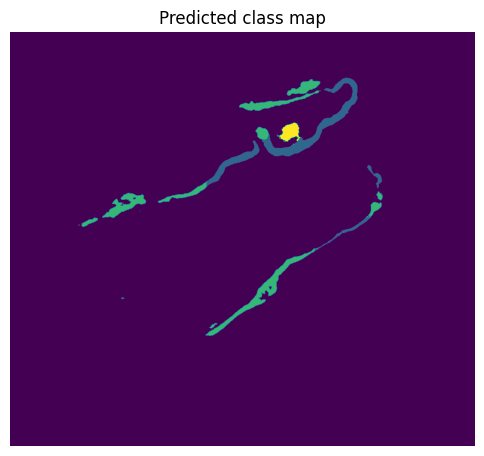

In [11]:
pred_np = pred  # already numpy
label_map = np.argmax(pred_np, axis=0)  # (H, W)

plt.figure(figsize=(6, 6))
plt.imshow(label_map)
plt.axis("off")
plt.title("Predicted class map")
plt.show()

### GENERATE ROIS

In [59]:
import slideflow as sf

SLIDE_PATH = "/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AG985F.svs"

# Create WSI object
wsi_pred = sf.WSI(
    path=SLIDE_PATH,
    tile_px=256,
    tile_um=128,
)

[14:21:41] INFO     No ROI for AG985F, using whole slide.

In [60]:
from slideflow.slide import qc

MODEL_PATH = "/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/models/seg_multiclass_v6/model.pth"

segmenter = qc.Segment(MODEL_PATH)

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/slideflow/segment/__init__.py:385: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load

In [61]:
#actually apply the segmenter to get our ROIs
roi_outlines = segmenter.generate_rois(wsi_pred)   # apply=True by default (meaning apply it to the wsi object which stores ROIS)

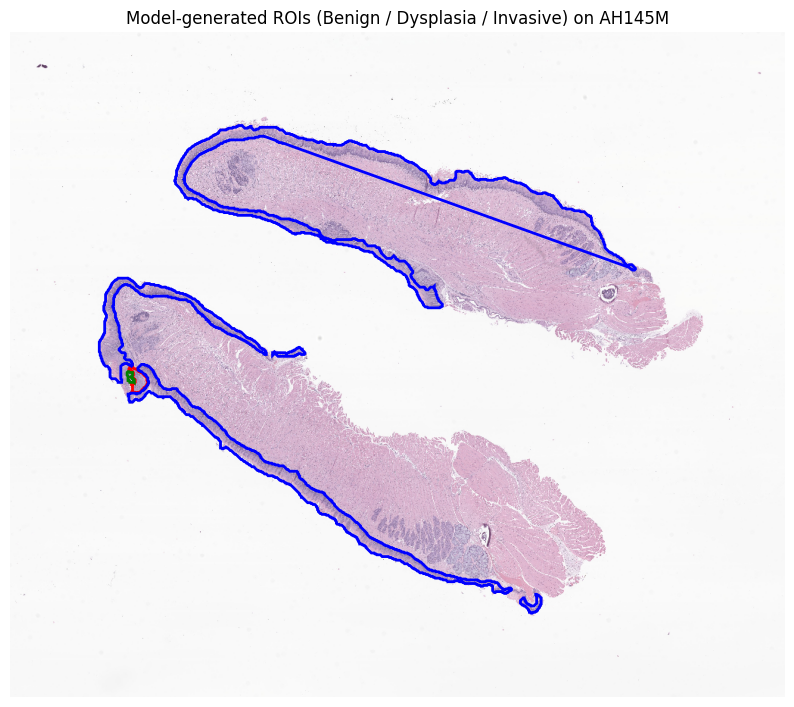

In [62]:
#now visualize the ROIs on the slide
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

# --- Thumbnail (no ROIs drawn yet) ---
thumb_pred = wsi_pred.thumb(width=1024, rois=False)

# Scale from full-res slide → thumbnail
orig_width, _ = wsi_pred.dimensions   # (width, height)
scale = thumb_pred.width / orig_width

# Color map for your 3 classes
color_map = {
    "benign": "blue",
    "dysplasia": "red",
    "invasive carcinoma": "green",
}

def overlay_rois(ax, wsi_obj, scale):
    for roi in wsi_obj.rois:
        geom = roi.poly

        if geom.geom_type == "Polygon":
            polygons = [geom]
        elif geom.geom_type == "MultiPolygon":
            polygons = list(geom.geoms)
        elif geom.geom_type == "GeometryCollection":
            # Keep only the polygonal parts
            polygons = [g for g in geom.geoms if g.geom_type == "Polygon"]
            if not polygons:
                # nothing polygonal to draw
                continue
        else:
            print(f"Unknown geometry type: {geom.geom_type} for ROI with label {roi.label}")
            continue

        raw_label = roi.label
        label = str(raw_label).lower() if raw_label is not None else "unknown"

        color_map = {
            "benign": "blue",
            "dysplasia": "red",
            "invasive carcinoma": "green",
        }
        color = color_map.get(label, "magenta")

        for poly in polygons:
            coords = np.array(poly.exterior.coords) * scale
            patch = MplPolygon(
                coords,
                closed=True,
                edgecolor=color,
                fill=False,
                linewidth=2,
            )
            ax.add_patch(patch)


# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(thumb_pred)
overlay_rois(ax, wsi_pred, scale)
ax.axis("off")
plt.title("Model-generated ROIs (Benign / Dysplasia / Invasive) on AH145M")

plt.show()


In [9]:
test_ds = dataset.filter({'dataset': ['test']})
test_ds.summary()

Overview:
╒═════════════════════╤════════════════════════════════════════════════════════════════════════╕
│ Configuration file: │ /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/datasets.json │
│ Tile size (px):     │                                                                        │
│ Tile size (um):     │                                                                        │
│ Slides:             │ 17                                                                     │
│ Patients:           │ 77                                                                     │
│ Slides with ROIs:   │ 17                                                                     │
│ Patients with ROIs: │ 17                                                                     │
╘═════════════════════╧════════════════════════════════════════════════════════════════════════╛

Filters:
╒═══════════════╤═══════════════════════╕
│ Filters:      │ {'dataset': ['test']} │
├───────────────┼──────

### Computing DICE and IOU

In [ ]:
#Computing DICE ---> by using the masks NOT the ROIs
#starting by getting ground truth masks
# exlore this method later

segment.export_thumbs_and_masks(
    dataset=test_ds,
    mpp=20,
    dest=EXPORT_DIR,
    mode="multiclass",
    labels=["Benign", "Dysplasia", "Invasive carcinoma"]
)


In [10]:
# Cmputing DICE and IOU using ROIs
from shapely.ops import unary_union
from shapely.geometry import GeometryCollection

#Assuming that the annotations cover the entire epithelium, so combine into one 
# object to get total area

def get_total_union(wsi_obj, area_threshold=0):
    """
    Combine all ROIs in the WSI object into a single geometry.
    
    Parameters:
      - wsi_obj: A slideflow.WSI object with ROI annotations.
      - area_threshold: (Optional) Only include polygons with area >= area_threshold.
    
    Returns:
      - A Shapely geometry (Polygon or MultiPolygon) representing the union of all ROIs,
        or an empty GeometryCollection if none are found.
    """
    polygons = []
    for roi in wsi_obj.rois:
        if roi.poly.geom_type == "Polygon":
            if roi.poly.area >= area_threshold:
                polygons.append(roi.poly)
        elif roi.poly.geom_type == "MultiPolygon":
            for subpoly in roi.poly.geoms:
                if subpoly.area >= area_threshold:
                    polygons.append(subpoly)
        else:
            print(f"Unknown geometry type: {roi.poly.geom_type} for ROI with label {roi.label}")
    
    if polygons:
        return unary_union(polygons)
    else:
        return GeometryCollection()




In [11]:
#Getting just the dysplasia ROIs combined to easily get area, etc

def get_dysplasia_union(wsi_obj, dysplasia_labels, area_threshold=0):
    """
    Combine only those ROIs in the WSI object that are labeled as dysplasia into one geometry.
    
    Parameters:
      - wsi_obj: A slideflow.WSI object with ROI annotations.
      - dysplasia_labels: A set of label strings that count as dysplasia (e.g., {"mild", "moderate", "severe", "dysplasia"}).
      - area_threshold: (Optional) Only include polygons with area >= area_threshold.
    
    Returns:
      - A Shapely geometry representing the union of dysplasia ROIs,
        or an empty geometry if none are found.
    """
    polygons = []
    for roi in wsi_obj.rois:
        label = roi.label.lower() if roi.label else "unknown"
        if label in dysplasia_labels:
            if roi.poly.geom_type == "Polygon":
                if roi.poly.area >= area_threshold:
                    polygons.append(roi.poly)
            elif roi.poly.geom_type == "MultiPolygon":
                for subpoly in roi.poly.geoms:
                    if subpoly.area >= area_threshold:
                        polygons.append(subpoly)
            else:
                print(f"Skipping unknown geometry type: {roi.poly.geom_type}")
    
    if polygons:
        return unary_union(polygons)
    else:
        return GeometryCollection()



In [12]:
#Getting just the dysplasia ROIs combined to easily get area, etc

def get_carcinoma_union(wsi_obj, carcinoma_labels, area_threshold=0):
    """
    Combine only those ROIs in the WSI object that are labeled as carcinoma into one geometry.
    
    Parameters:
      - wsi_obj: A slideflow.WSI object with ROI annotations.
      - carcinoma_labels: A set of label strings that count as carcinoma (e.g., {"mild", "moderate", "severe", "carcinoma"}).
      - area_threshold: (Optional) Only include polygons with area >= area_threshold.
    
    Returns:
      - A Shapely geometry representing the union of carcinoma ROIs,
        or an empty geometry if none are found.
    """
    polygons = []
    for roi in wsi_obj.rois:
        label = roi.label.lower() if roi.label else "unknown"
        if label in carcinoma_labels:
            if roi.poly.geom_type == "Polygon":
                if roi.poly.area >= area_threshold:
                    polygons.append(roi.poly)
            elif roi.poly.geom_type == "MultiPolygon":
                for subpoly in roi.poly.geoms:
                    if subpoly.area >= area_threshold:
                        polygons.append(subpoly)
            else:
                print(f"Skipping unknown geometry type: {roi.poly.geom_type}")
    
    if polygons:
        return unary_union(polygons)
    else:
        return GeometryCollection()

In [13]:
#Getting just the dysplasia ROIs combined to easily get area, etc

def get_benign_union(wsi_obj, benign_labels, area_threshold=0):
    """
    Combine only those ROIs in the WSI object that are labeled as benign into one geometry.
    
    Parameters:
      - wsi_obj: A slideflow.WSI object with ROI annotations.
      - benign_labels: A set of label strings that count as benign (e.g., {"benign"}).
      - area_threshold: (Optional) Only include polygons with area >= area_threshold.
    
    Returns:
      - A Shapely geometry representing the union of benign ROIs,
        or an empty geometry if none are found.
    """
    polygons = []
    for roi in wsi_obj.rois:
        label = roi.label.lower() if roi.label else "unknown"
        if label in benign_labels:
            if roi.poly.geom_type == "Polygon":
                if roi.poly.area >= area_threshold:
                    polygons.append(roi.poly)
            elif roi.poly.geom_type == "MultiPolygon":
                for subpoly in roi.poly.geoms:
                    if subpoly.area >= area_threshold:
                        polygons.append(subpoly)
            else:
                print(f"Skipping unknown geometry type: {roi.poly.geom_type}")
    
    if polygons:
        return unary_union(polygons)
    else:
        return GeometryCollection()

In [14]:

#Note that we are inputting objects that represents union of the 
#DYSPLASIA ROIS. When you call intersection, it can find the area where they overlap
#using the boundary and interior points. The union object is not just an area, it retains 
#the BOUNDARY points. 
def compute_overlap_metrics(union_A, union_B):
    """
    Given two Shapely geometries (unions of dysplasia annotations from two pathologists),
    compute the overlap metrics: intersection area, IoU, and Dice coefficient.
    
    Parameters:
      - union_A: Shapely geometry for pathologist A's dysplasia.
      - union_B: Shapely geometry for pathologist B's dysplasia.
      
    Returns:
      - intersection_area: Area where both annotations overlap.
      - iou: Intersection over Union metric.
      - dice: Dice coefficient.
    """
    # Compute the intersection area between the two unions.
    intersection_area = union_A.intersection(union_B).area
    
    # Compute the union of both annotations (for IoU).
    #This is just Area A + B - intersection area
    combined_union_area = union_A.union(union_B).area
    
    # Compute IoU (Jaccard Index). Avoid division by zero.
    iou = intersection_area / combined_union_area if combined_union_area > 0 else 0
    
    # Compute Dice coefficient. Avoid division by zero.
    total_area = union_A.area + union_B.area
    dice = (2 * intersection_area) / total_area if total_area > 0 else 0
    
    return intersection_area, iou, dice

In [ ]:
# Calculate dysplasia percentages and overlap metrics for both pathologists
dysplasia_labels = {"dysplasia", "mild", "moderate", "severe"}
benign_labels = {"benign"}


#Note: We are comparing WSI prediction vs grouth truth (Anna ROis)
# In the code in above sections, we have run the moel on our wsi_pred object to generate ROIs! 
# So now we just need to define Anna's wsi object 

wsi_anna = sf.WSI(
    path = "/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AH145M.svs",
    tile_px = 256,
    tile_um = 128,
    rois = "/home/stanna/Cancer_Project_2025/Anna/exp2/AH145M.csv"
)


#generate the thumbnails
thumb_anna = wsi_anna.thumb(width=1024, rois=False)
thumb_pred = wsi_pred.thumb(width=1024, rois=False)




# Get pixels per micron conversion factors
#change all grayson to pred using wsi_pred object

mpp_pred = wsi_pred.mpp
mpp_anna = wsi_anna.mpp

# Get union of all ROIs (total epithelium)
total_union_pred = get_total_union(wsi_pred, area_threshold=0)
total_union_anna = get_total_union(wsi_anna, area_threshold=0)

# Get union of dysplasia ROIs only
dys_union_pred = get_dysplasia_union(wsi_pred, dysplasia_labels, area_threshold=0)
dys_union_anna = get_dysplasia_union(wsi_anna, dysplasia_labels, area_threshold=0)

benign_union_pred = get_benign_union(wsi_pred, benign_labels, area_threshold=0)
benign_union_anna = get_benign_union(wsi_anna, benign_labels, area_threshold=0)


# Convert areas to square microns
total_area_pred = total_union_pred.area * (mpp_pred**2)
dys_area_pred = dys_union_pred.area * (mpp_pred**2)

total_area_anna = total_union_anna.area * (mpp_anna**2)
dys_area_anna = dys_union_anna.area * (mpp_anna**2)

# Calculate dysplasia percentages
dys_percentage_pred = (dys_area_pred / total_area_pred) * 100
dys_percentage_anna = (dys_area_anna / total_area_anna) * 100

# Calculate overlap metrics using the dysplasia ROIs 
intersection_area, iou, dice = compute_overlap_metrics(dys_union_pred, dys_union_anna)
intersection_area = intersection_area * (mpp_pred**2)

# Display results
# print(f"Total annotated area pred: {total_area_pred}")
# print(f"Dysplasia area pred: {dys_area_pred}")
# print(f"Percentage dysplasia pred: {dys_percentage_pred:.2f}%")

# print(f"Total annotated area anna: {total_area_anna}")
# print(f"Dysplasia area anna: {dys_area_anna}")
# print(f"Percentage dysplasia anna: {dys_percentage_anna:.2f}%")

# print("Intersection Area:", intersection_area)
# print("IoU (Jaccard Index):", iou)
# print("Dice Coefficient:", dice)

print(f"Intersection Area: {intersection_area}")
print(f"IoU (Jaccard Index): {iou}")
print(f"Dice Coefficient: {dice}")


Intersection Area: 2666628.145733351
IoU (Jaccard Index): 0.3512732549037684
Dice Coefficient: 0.5199144638273548


Next task: automate this process by creating an overall loop
    1. Loop through traning data 
    2. Create Anna and WSI_pred object
    3. Call function to generate ROIs on WSI_pred
    4. Find IOU and Dice (may have to get IOU and DICE for dyslasia regions, benign regions, and overall)
    5. Append to df 
    6. go to iteration
    7. Output final df with slide, IOU, DICE

### IOU and DICE on ALL training (loop)

In [15]:
import slideflow as sf

# # Load a project and dataset
project = sf.load_project('/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo')
# dataset = project.dataset(sources=['Exp1'])
dataset = project.dataset(sources=['Exp2_Dataset'])

In [16]:
test = dataset.filter({'dataset': ['test']})
test.summary()


Overview:
╒═════════════════════╤════════════════════════════════════════════════════════════════════════╕
│ Configuration file: │ /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/datasets.json │
│ Tile size (px):     │                                                                        │
│ Tile size (um):     │                                                                        │
│ Slides:             │ 17                                                                     │
│ Patients:           │ 77                                                                     │
│ Slides with ROIs:   │ 17                                                                     │
│ Patients with ROIs: │ 17                                                                     │
╘═════════════════════╧════════════════════════════════════════════════════════════════════════╛

Filters:
╒═══════════════╤═══════════════════════╕
│ Filters:      │ {'dataset': ['test']} │
├───────────────┼──────

In [17]:
#create slide dict that maps slide base name to slide path
#Since we are testing on 17 slides they are all found in these directories. Note that there is another directory wth slides but not used rn

import os

slides_dir_1 = "/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO"
slides_dir_2 = "/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM"

svs_map = {}

for directory in [slides_dir_1, slides_dir_2]:
    for filename in os.listdir(directory):
        if filename.endswith(".svs"):
            base_name = filename.replace(".svs", "")
            svs_map[base_name] = os.path.join(directory, filename)


In [18]:
#load the model and create segmenter to generate ROIs

from slideflow.slide import qc

MODEL_PATH = "/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/models/seg_multiclass_v6/model.pth"

segmenter = qc.Segment(MODEL_PATH)

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/slideflow/segment/__init__.py:385: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load

In [19]:
def safe_overlap(pred_union, gt_union):
    """
    Returns (intersection_area, iou, dice) but doesn't crash if either union is empty.
    Assumes pred_union/gt_union are shapely geometries.
    """
    if pred_union is None or gt_union is None:
        return 0.0, 0.0, 0.0
    if pred_union.is_empty and gt_union.is_empty:
        return 0.0, 1.0, 1.0  # both empty = perfect agreement (optional choice)
    if pred_union.is_empty or gt_union.is_empty:
        return 0.0, 0.0, 0.0

    return compute_overlap_metrics(pred_union, gt_union)

In [20]:
#start by looping through my test slides
#Note this is only being applied to our testing slides 
import os
import pandas as pd


rows = []
#Note that thsi should be changed now. All ROIs are now stored via labshare
# ROI_DIR = "/home/stanna/Cancer_Project_2025/Anna/exp2"
ROI_DIR = "/home/stanna/labshare/SLIDES/PDCD10/ROI/anna"
test_slides = test.slides() 


benign_labels     = {"benign"}
dysplasia_labels  = {"dysplasia"}
carcinoma_labels  = {"invasive carcinoma"}


for slide in test_slides:
    #get slide path
    slide_path = svs_map[slide]
    # get roi path (for gt object)
    roi_path = os.path.join(ROI_DIR, f"{slide}.csv")

    if not os.path.exists(roi_path):
        raise FileNotFoundError(f"Missing ROI CSV for slide {slide}")


    #create wsi_pred object
    wsi_pred = sf.WSI(
        path = slide_path,
        tile_px = 256,
        tile_um = 128,
    )
    #actually apply the segmenter to get our ROIs
    roi_outlines = segmenter.generate_rois(wsi_pred) 

    #create wsi_anna object
    wsi_anna = sf.WSI(
        path = slide_path,
        tile_px = 256,
        tile_um = 128,
        rois = roi_path
    )
    # Get union of all ROIs (total epithelium)
    total_union_pred = get_total_union(wsi_pred, area_threshold=0)
    total_union_anna = get_total_union(wsi_anna, area_threshold=0)

    # Get union of dysplasia ROIs only
    dys_union_pred = get_dysplasia_union(wsi_pred, dysplasia_labels, area_threshold=0)
    dys_union_anna = get_dysplasia_union(wsi_anna, dysplasia_labels, area_threshold=0)

    # Get union of carcinoma ROIs only
    carcinoma_union_pred = get_carcinoma_union(wsi_pred, carcinoma_labels, area_threshold=0)
    carcinoma_union_anna = get_carcinoma_union(wsi_anna, carcinoma_labels, area_threshold=0)

    # Get union of benign ROIs only
    benign_union_pred = get_benign_union(wsi_pred, benign_labels, area_threshold=0)
    benign_union_anna = get_benign_union(wsi_anna, benign_labels, area_threshold=0)
    
    #computing the IOU and DICE (ignoring first value because that's intersection area don't need it!)
    _, benign_iou, benign_dice = safe_overlap(benign_union_pred, benign_union_anna)
    _, dys_iou, dys_dice       = safe_overlap(dys_union_pred, dys_union_anna)
    _, ca_iou, ca_dice         = safe_overlap(carcinoma_union_pred, carcinoma_union_anna)

    #append to rows
    rows.append({
        "slide": slide,
        "benign_iou": benign_iou,
        "benign_dice": benign_dice,
        "dysplasia_iou": dys_iou,
        "dysplasia_dice": dys_dice,
        "carcinoma_iou": ca_iou,
        "carcinoma_dice": ca_dice,
        "mean_iou": (benign_iou + dys_iou + ca_iou) / 3,
        "mean_dice": (benign_dice + dys_dice + ca_dice) / 3,
    })

results_df = pd.DataFrame(rows)


[13:54:16] INFO     No ROI for AG985F, using whole slide.

Unknown geometry type: GeometryCollection for ROI with label Benign
Skipping unknown geometry type: GeometryCollection


[13:54:19] INFO     No ROI for AG986F, using whole slide.

[13:54:20] INFO     No ROI for AG987F, using whole slide.

[13:54:22] INFO     No ROI for AG991M, using whole slide.

...

[13:54:47] INFO     No ROI for AH212F, using whole slide.

[13:54:48] INFO     No ROI for AH213F, using whole slide.

Unknown geometry type: GeometryCollection for ROI with label Dysplasia
Skipping unknown geometry type: GeometryCollection


[13:54:50] INFO     No ROI for AH215M, using whole slide.

Unknown geometry type: GeometryCollection for ROI with label Invasive carcinoma
Skipping unknown geometry type: GeometryCollection


In [30]:
results_df

,slide,benign_iou,benign_dice,dysplasia_iou,dysplasia_dice,carcinoma_iou,carcinoma_dice,mean_iou,mean_dice
0,AG985F,0.224627,0.366850,0.057329,0.108440,0.020377,0.039939,0.100777,0.171743
1,AG986F,0.256912,0.408799,0.045190,0.086472,0.000000,0.000000,0.100701,0.165090
2,AG987F,0.166798,0.285907,0.027663,0.053836,0.000000,0.000000,0.064820,0.113248
3,AG991M,0.397115,0.568478,0.041508,0.079708,0.278243,0.435352,0.238955,0.361180
4,AH063F,0.078123,0.144925,0.111067,0.199928,0.000000,0.000000,0.063063,0.114951
5,AH073M,0.128990,0.228505,0.009410,0.018645,0.000000,0.000000,0.046133,0.082383
6,AH074M,0.335840,0.502814,0.105137,0.190269,0.065132,0.122299,0.168703,0.271794
7,AH139F,0.280390,0.437976,0.037297,0.071911,0.070516,0.131741,0.129401,0.213876
8,AH141F,0.069402,0.129795,0.013168,0.025994,0.059232,0.111839,0.047267,0.089209
9,AH142F,0.150242,0.261236,0.055450,0.105074,0.067960,0.127271,0.091218,0.164527


In [29]:
#create per class boxplot

import pandas as pd

iou_long = []

iou_long = pd.DataFrame({
    "IoU": pd.concat([
        results_df["benign_iou"],
        results_df["dysplasia_iou"],
        results_df["carcinoma_iou"],
    ], ignore_index=True),
    "Class": (
        ["Benign"] * len(results_df) +
        ["Dysplasia"] * len(results_df) +
        ["Carcinoma"] * len(results_df)
    )
})



In [30]:
iou_long

,IoU,Class
0,0.033542,Benign
1,0.558367,Benign
2,0.054047,Benign
3,0.000000,Benign
4,0.526655,Dysplasia
5,0.635045,Dysplasia
6,0.579262,Dysplasia
7,0.504559,Dysplasia
8,0.000000,Carcinoma
9,0.353808,Carcinoma


/tmp/ipykernel_440426/57858389.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


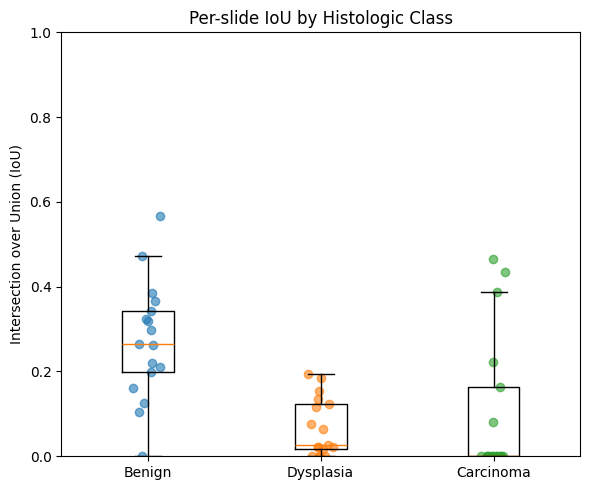

In [21]:
import numpy as np
import matplotlib.pyplot as plt

data = []

data = [
    results_df["benign_iou"],
    results_df["dysplasia_iou"],
    results_df["carcinoma_iou"],
]

labels = ["Benign", "Dysplasia", "Carcinoma"]

plt.figure(figsize=(6, 5))
plt.boxplot(data, labels=labels, showfliers=False)

for i, vals in enumerate(data, start=1):
    x = np.random.normal(i, 0.04, size=len(vals))  # jitter
    plt.scatter(x, vals, alpha=0.6)

plt.ylabel("Intersection over Union (IoU)")
plt.title("Per-slide IoU by Histologic Class")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_440426/15848248.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


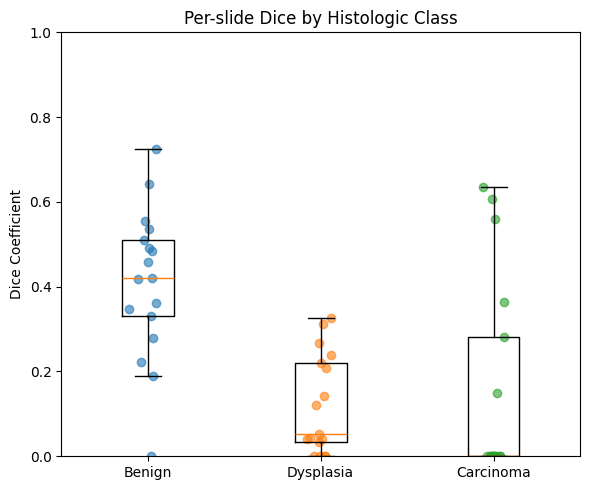

In [22]:
import matplotlib.pyplot as plt
import numpy as np

data = []

data = [
    results_df["benign_dice"],
    results_df["dysplasia_dice"],
    results_df["carcinoma_dice"],
]

labels = ["Benign", "Dysplasia", "Carcinoma"]

plt.figure(figsize=(6, 5))

# Boxplot (no outlier symbols since we show all points)
plt.boxplot(data, labels=labels, showfliers=False)

# Overlay individual slide points with jitter
for i, vals in enumerate(data, start=1):
    x = np.random.normal(i, 0.04, size=len(vals))  # horizontal jitter
    plt.scatter(x, vals, alpha=0.6)

plt.ylabel("Dice Coefficient")
plt.title("Per-slide Dice by Histologic Class")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


next steps can be to go back and filter for cases where there is no actual carcinoma so our carcinoma DICE and IOU avgs aren't being grought down

Then we could also do some visualization in the loop to see the pred vs gt slide 

retrain on more slides? 